In [20]:
import pyaudio
import numpy as np
import matplotlib.pyplot as plt

# Constants
FORMAT = pyaudio.paFloat32
CHANNELS = 1
RATE = 44100
CHUNK = 1024
RECORD_SECONDS = 5

# Initialize PyAudio
audio = pyaudio.PyAudio()

# Open stream
stream = audio.open(format=FORMAT, channels=CHANNELS,
                    rate=RATE, input=True,
                    frames_per_buffer=CHUNK)

print("Recording...")

frames = []

# Record for a few seconds
for _ in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
    data = stream.read(CHUNK)
    frames.append(data)

print("Finished recording.")

# Stop and close the stream
stream.stop_stream()
stream.close()
audio.terminate()

# Convert the list of frames to a byte string, then to a numpy array
signal = np.frombuffer(b''.join(frames), dtype='float32')

# Perform FFT
fft_result = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(fft_result), d=1/RATE)

Recording...
Finished recording.


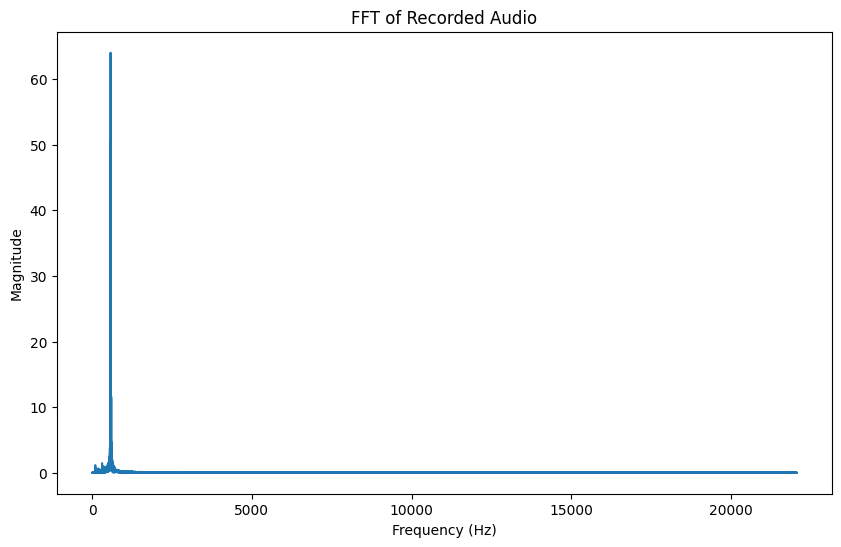

In [21]:
# Compute the magnitude (absolute value) of the FFT
magnitude = np.abs(fft_result)

# Plot FFT
plt.figure(figsize=(10, 6))
plt.plot(frequencies[:len(frequencies)//2], magnitude[:len(frequencies)//2])
plt.title("FFT of Recorded Audio")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
# plt.xlim(0, 1000)
plt.show()